# Trading Activity Overview: NASDAQ Market Structure

**Chapter 3: Market Microstructure**

**Docker image**: `ml4t`

## Purpose

Provide the chapter's market-wide ITCH context: aggregate message-type
composition, dollar-volume concentration across tickers, and the canonical
enriched-trade parquet that `06_itch_intraday_patterns` and
`07_itch_stylized_facts` reuse.

## Learning Objectives

After completing this notebook, you will be able to:
- Tally ITCH message types across a multi-day sample and place add/cancel/
  execute frequencies in proportion.
- Build a stock-attributed trade table by joining `E`/`C`/`X` messages to the
  `R`-based `stock_locate → stock` directory and to `A`/`F` add-order
  attributes (with `U` replace lineage).
- Quantify dollar-volume concentration (Pareto-style) over the universe.

## Book reference

Section §3.3, *From Raw Messages to the Limit Order Book* — the
market-wide statistics paragraph cites this notebook.

## Prerequisites

- Parsed ITCH message parquets at `data/equities/market/microstructure/nasdaq_itch/messages/`
  (output of `01_itch_parser` or the Rust parser).
- Notebooks 06 and 07 read the canonical trade table this notebook writes
  under `output/ch03/nasdaq_itch/trading_activity/`.

---

## 1. Setup and Configuration

In [1]:
"""Trading Activity Overview — high-level view of NASDAQ trading activity using TotalView-ITCH data."""

import warnings
from pathlib import Path

warnings.filterwarnings("ignore")

import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import numpy as np
import polars as pl
import pyarrow.dataset as ds
import seaborn as sns
from IPython.display import display

from data import load_nasdaq_itch
from utils.paths import get_output_dir

sns.set_style("whitegrid")

In [2]:
# Production defaults
MAX_ROWS = 0

In [3]:
# Configuration - Unified output directory structure
# All ITCH-related outputs under a single chapter directory
NASDAQ_ITCH_OUTPUT = get_output_dir(3, "nasdaq_itch")

# Input: Parsed messages from canonical loader path
MESSAGE_DIR = load_nasdaq_itch(get_base_path=True)

# Output: This notebook's analysis outputs
# Trade summary is consumed by notebooks 06 and 07
OUTPUT_DIR = NASDAQ_ITCH_OUTPUT / "trading_activity"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

ROW_LIMIT = MAX_ROWS or None

print(f"Input directory (messages): {MESSAGE_DIR}")
print(f"Output directory (analysis): {OUTPUT_DIR}")

if not MESSAGE_DIR.exists():
    print(f"\nWARNING: Message directory not found: {MESSAGE_DIR}")
    print("   Run 01_itch_parser first to parse ITCH data.")
    available = []
else:
    available = sorted([d.name for d in MESSAGE_DIR.iterdir() if d.is_dir()])
    print(f"\nAvailable message types: {available}")

# Check if we have message data to analyze
HAS_MESSAGE_DATA = len(available) > 0

if not HAS_MESSAGE_DATA:
    raise RuntimeError(
        "No parsed ITCH message data found.\n"
        "This notebook requires output from 01_itch_parser (full parse ~60min).\n"
        f"Expected directory: {MESSAGE_DIR}"
    )

Input directory (messages): /home/stefan/ml4t/code/data/equities/market/microstructure/nasdaq_itch/messages
Output directory (analysis): /home/stefan/ml4t/code/03_market_microstructure/output/nasdaq_itch/trading_activity

Available message types: ['A', 'C', 'D', 'E', 'F', 'H', 'I', 'J', 'K', 'L', 'P', 'Q', 'R', 'S', 'U', 'V', 'X', 'Y']


## 2. Counting Messages by Type

Each message type is stored in its own Parquet subdirectory. Let's see how many messages
of each type exist in our dataset.

In [4]:
def count_parquet_rows(base_dir: Path) -> dict[str, int]:
    """
    Count total rows (messages) in each Parquet subdirectory.

    Args:
        base_dir: Directory containing subfolders like A/, C/, E/, etc.

    Returns:
        Mapping from subfolder name (e.g. 'A') to total row count.
    """
    message_counts = {}
    for sub in sorted(base_dir.iterdir()):
        if sub.is_dir():
            try:
                dset = ds.dataset(sub.as_posix(), format="parquet")
                total_rows = sum(frag.metadata.num_rows for frag in dset.get_fragments())
                message_counts[sub.name] = total_rows
            except (OSError, FileNotFoundError) as e:
                print(f"Error reading {sub.name}: {e}")
            except Exception as e:
                # Log unexpected errors for debugging
                print(f"Unexpected error reading {sub.name}: {type(e).__name__}: {e}")
    return message_counts

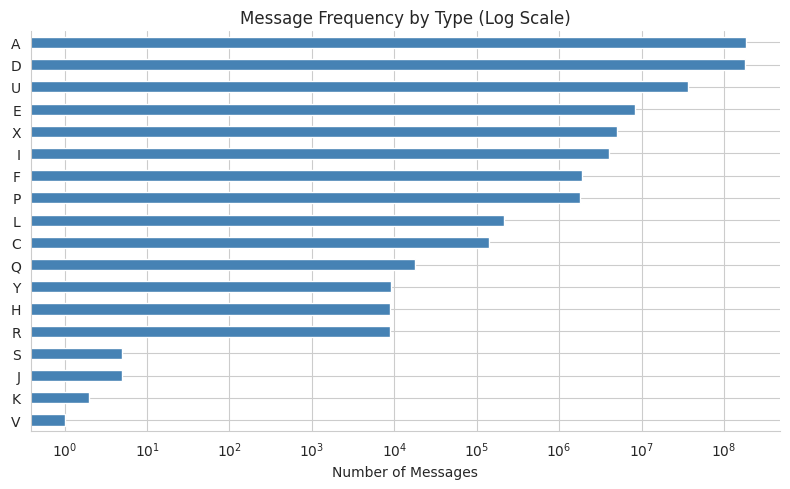


Message Type Summary:
  A:  184,735,355
  D:  180,285,101
  U:   36,777,372
  E:    8,415,610
  X:    4,990,972
  I:    4,025,192
  F:    1,875,350
  P:    1,779,727
  L:      216,802
  C:      139,474
  Q:       17,835
  Y:        9,068
  H:        8,921
  R:        8,916
  J:            5
  S:            5
  K:            2
  V:            1


In [5]:
if HAS_MESSAGE_DATA:
    message_summary = count_parquet_rows(MESSAGE_DIR)

    # Convert to pandas for plotting (matplotlib expects pandas)
    import pandas as pd

    fig, ax = plt.subplots(figsize=(8, 5))
    pd.Series(message_summary).sort_values().plot.barh(ax=ax, color="steelblue")
    # Counts span nine orders of magnitude (adds ~185M vs. rare admin types in
    # single digits) — a log axis keeps every message type legible.
    ax.set_xscale("log")
    ax.set_title("Message Frequency by Type (Log Scale)")
    ax.set_xlabel("Number of Messages")
    sns.despine()
    plt.tight_layout()
    plt.show()

    # Print summary
    print("\nMessage Type Summary:")
    for msg_type, count in sorted(message_summary.items(), key=lambda x: -x[1]):
        print(f"  {msg_type}: {count:>12,}")

### Message Type Reference

| Type | Name | Description |
|------|------|-------------|
| **A** | Add Order | New limit order enters the book |
| **F** | Add Order (Attributed) | Same as A, with market participant ID |
| **E** | Order Executed | Partial/full execution |
| **C** | Order Executed w/Price | Execution at different price |
| **X** | Order Cancel | Partial cancellation |
| **D** | Order Delete | Full removal from book |
| **P** | Trade | Non-displayed execution |
| **Q** | Cross Trade | Opening/closing cross |

## 3. Execution Attribution: Enriching E/C Messages

E (Order Executed) and C (Order Executed with Price) messages contain `stock_locate`
but not the stock symbol. We enrich them by joining to:

1. **R messages**: `stock_locate → stock` mapping (basic attribution)
2. **A/F messages**: `order_ref → (price, side)` (execution quality analysis)

This enables filtering trades by stock symbol and analyzing execution quality.

**Note**: This enrichment is performed here in notebook 05, not notebook 01.
The enriched files are saved to `messages/enriched/` and reused by downstream
notebooks (04, 06, 07) that need stock-level execution data.

In [6]:
def _build_stock_directory(message_dir: Path) -> pl.DataFrame | None:
    """Load stock_locate -> stock mapping from R (Stock Directory) messages."""
    r_path = message_dir / "R"
    if not r_path.exists():
        print("No R (Stock Directory) messages found. Cannot enrich.")
        return None

    print("Building stock_locate -> stock mapping from R messages...")
    stock_directory = (
        pl.scan_parquet(r_path / "*.parquet").select("stock_locate", "stock").collect()
    )
    print(f"  {len(stock_directory):,} stocks in directory")
    return stock_directory

### Build Order Attributes
Map order references to their price, side, and stock from A/F messages.

In [7]:
def _build_order_attrs(message_dir: Path) -> pl.DataFrame | None:
    """Build order_ref -> (price, side, stock) mapping from A/F messages."""
    print("Building order_ref -> attributes mapping from A/F messages...")

    a_path = message_dir / "A"
    if not a_path.exists():
        print("No A (Add Order) messages found. Cannot enrich.")
        return None

    orders_a = pl.scan_parquet(a_path / "*.parquet").select(
        "order_reference_number",
        "price",
        "buy_sell_indicator",
        "stock",
    )

    # F messages have same structure plus attribution (MPID)
    f_path = message_dir / "F"
    if f_path.exists() and list(f_path.glob("*.parquet")):
        orders_f = pl.scan_parquet(f_path / "*.parquet").select(
            "order_reference_number",
            "price",
            "buy_sell_indicator",
            "stock",
        )
        order_attrs = pl.concat([orders_a, orders_f]).collect()
    else:
        order_attrs = orders_a.collect()

    print(f"  {len(order_attrs):,} orders with attributes")
    return order_attrs

### Apply Order Replacements
Incorporate U (Replace) messages so new order references inherit original attributes.

In [8]:
def _apply_replacements(message_dir: Path, order_attrs: pl.DataFrame) -> pl.DataFrame:
    """Incorporate U (Replace) messages so new_order_ref inherits original attributes."""
    u_path = message_dir / "U"
    if not (u_path.exists() and list(u_path.glob("*.parquet"))):
        return order_attrs

    print("Processing U (Replace) messages for order lineage...")
    replacements = (
        pl.scan_parquet(u_path / "*.parquet")
        .select(
            "original_order_reference_number",
            "new_order_reference_number",
            "price",  # U messages have updated price
        )
        .collect()
    )

    # For each replacement, look up the original order's attributes
    replaced = (
        replacements.join(
            order_attrs.select("order_reference_number", "buy_sell_indicator", "stock"),
            left_on="original_order_reference_number",
            right_on="order_reference_number",
            how="left",
        )
        .select(
            pl.col("new_order_reference_number").alias("order_reference_number"),
            "price",  # Use the NEW price from U message
            "buy_sell_indicator",
            "stock",
        )
        .drop_nulls()
    )

    print(f"  {len(replaced):,} replacement orders tracked")
    return pl.concat([order_attrs, replaced])

### Enrich E Messages
Add stock symbol and order attributes to Order Executed messages.

In [9]:
def _enrich_e_messages(
    message_dir: Path, enriched_dir: Path, stock_directory: pl.DataFrame, order_attrs: pl.DataFrame
) -> int | None:
    """Enrich E (Order Executed) messages with stock and order attributes."""
    e_path = message_dir / "E"
    if not e_path.exists():
        return None

    print("Enriching E (Order Executed) messages...")
    executions_e = pl.scan_parquet(e_path / "*.parquet").collect()

    # Join to get stock from stock_locate
    enriched_e = executions_e.join(stock_directory, on="stock_locate", how="left")

    # Join to get order attributes (price, side)
    enriched_e = enriched_e.join(
        order_attrs.select(
            "order_reference_number",
            pl.col("price").alias("order_price"),
            pl.col("buy_sell_indicator").alias("side"),
        ),
        on="order_reference_number",
        how="left",
    )

    # E messages execute at the order's limit price
    enriched_e = enriched_e.with_columns(pl.col("order_price").alias("execution_price"))

    enriched_e.write_parquet(enriched_dir / "E.parquet")
    matched = enriched_e.filter(pl.col("stock").is_not_null()).height
    count = len(enriched_e)
    print(f"  {count:,} executions enriched ({matched:,} with stock match)")
    return count

### Enrich C Messages
Add stock symbol and order attributes to Order Executed with Price messages.

In [10]:
def _enrich_c_messages(
    message_dir: Path, enriched_dir: Path, stock_directory: pl.DataFrame, order_attrs: pl.DataFrame
) -> int | None:
    """Enrich C (Order Executed with Price) messages — includes price improvement."""
    c_path = message_dir / "C"
    if not c_path.exists():
        return None

    print("Enriching C (Order Executed with Price) messages...")
    executions_c = pl.scan_parquet(c_path / "*.parquet").collect()

    enriched_c = executions_c.join(stock_directory, on="stock_locate", how="left")

    enriched_c = enriched_c.join(
        order_attrs.select(
            "order_reference_number",
            pl.col("price").alias("order_price"),
            pl.col("buy_sell_indicator").alias("side"),
        ),
        on="order_reference_number",
        how="left",
    )

    # C messages have execution_price - can compute price improvement
    enriched_c = enriched_c.with_columns(
        (pl.col("execution_price").cast(pl.Int64) - pl.col("order_price").cast(pl.Int64)).alias(
            "price_improvement_raw"
        )
    )

    enriched_c.write_parquet(enriched_dir / "C.parquet")
    count = len(enriched_c)
    print(f"  {count:,} executions with price enriched")
    return count

### Enrich X Messages
Add stock symbol to Order Cancel messages.

In [11]:
def _enrich_x_messages(
    message_dir: Path, enriched_dir: Path, stock_directory: pl.DataFrame
) -> int | None:
    """Enrich X (Order Cancel) messages with stock symbol."""
    x_path = message_dir / "X"
    if not x_path.exists():
        return None

    print("Enriching X (Order Cancel) messages...")
    cancels = pl.scan_parquet(x_path / "*.parquet").collect()

    enriched_x = cancels.join(stock_directory, on="stock_locate", how="left")

    enriched_x.write_parquet(enriched_dir / "X.parquet")
    count = len(enriched_x)
    print(f"  {count:,} cancellations enriched")
    return count

### Enrich Execution Messages
Orchestrate enrichment of E/C/X messages with stock symbols and order attributes.

In [12]:
def enrich_execution_messages(message_dir: Path) -> dict[str, int]:
    """
    Enrich E/C/X messages with stock symbol and order attributes.

    Creates enriched Parquet files that enable:
    - Filtering executions by stock symbol
    - Execution quality analysis (fill price vs limit price)
    - Fill rate analysis by order characteristics

    Returns count of enriched messages by type.
    """
    enriched_dir = message_dir / "enriched"
    enriched_dir.mkdir(exist_ok=True)

    stock_directory = _build_stock_directory(message_dir)
    if stock_directory is None:
        return {}

    order_attrs = _build_order_attrs(message_dir)
    if order_attrs is None:
        return {}
    order_attrs = _apply_replacements(message_dir, order_attrs)

    counts = {}
    for label, fn in [
        ("E", lambda: _enrich_e_messages(message_dir, enriched_dir, stock_directory, order_attrs)),
        ("C", lambda: _enrich_c_messages(message_dir, enriched_dir, stock_directory, order_attrs)),
        ("X", lambda: _enrich_x_messages(message_dir, enriched_dir, stock_directory)),
    ]:
        result = fn()
        if result is not None:
            counts[label] = result

    print(f"\nEnriched files saved to: {enriched_dir}")
    return counts

In [13]:
# Run enrichment if parsed data exists and enriched files don't
if HAS_MESSAGE_DATA and (MESSAGE_DIR / "R").exists():
    enriched_dir = MESSAGE_DIR / "enriched"
    # Check if enrichment already done
    if not (enriched_dir / "E.parquet").exists():
        print("Running execution enrichment...")
        enrichment_counts = enrich_execution_messages(MESSAGE_DIR)
        print("\n=== Enrichment Summary ===")
        for msg_type, count in enrichment_counts.items():
            print(f"  {msg_type}: {count:,} messages")
    else:
        print(f"Enriched files already exist in {enriched_dir}")
        print("  Delete the directory and re-run to regenerate.")

Running execution enrichment...
Building stock_locate -> stock mapping from R messages...


  8,916 stocks in directory
Building order_ref -> attributes mapping from A/F messages...


  186,610,705 orders with attributes
Processing U (Replace) messages for order lineage...


  7,900,629 replacement orders tracked
Enriching E (Order Executed) messages...


  8,415,614 executions enriched (8,415,614 with stock match)
Enriching C (Order Executed with Price) messages...


  139,474 executions with price enriched
Enriching X (Order Cancel) messages...


  4,990,973 cancellations enriched

Enriched files saved to: /home/stefan/ml4t/code/data/equities/market/microstructure/nasdaq_itch/messages/enriched

=== Enrichment Summary ===
  E: 8,415,614 messages
  C: 139,474 messages
  X: 4,990,973 messages


## 4. Trade Volume and Value by Ticker

We analyze **executions** (trades) from message types that reflect actual trades:
- `'C'`: Order Executed with Price
- `'E'`: Order Executed
- `'P'`: Trade (regular)
- `'Q'`: Cross Trade

In [14]:
def _unify_columns(df: pl.DataFrame, msg_type: str) -> pl.DataFrame | None:
    """Normalize column names across ITCH message types to a common schema."""
    cols = {c.lower(): c for c in df.columns}

    # Unify 'shares' column
    if "executed_shares" in cols:
        df = df.with_columns(pl.col(cols["executed_shares"]).cast(pl.Float64).alias("shares"))
    elif "shares" in cols:
        df = df.with_columns(pl.col(cols["shares"]).cast(pl.Float64).alias("shares"))
    else:
        return None

    # Unify 'price' column
    if "execution_price" in cols:
        df = df.with_columns(pl.col(cols["execution_price"]).cast(pl.Float64).alias("price"))
    elif "cross_price" in cols:
        df = df.with_columns(pl.col(cols["cross_price"]).cast(pl.Float64).alias("price"))
    elif "price" in cols:
        df = df.with_columns(pl.col(cols["price"]).cast(pl.Float64).alias("price"))
    else:
        return None

    # Handle timestamp
    if "timestamp" in cols:
        df = df.with_columns(pl.col(cols["timestamp"]).alias("timestamp"))

    # Handle ticker (may be 'stock' or 'ticker')
    if "ticker" in cols:
        df = df.with_columns(pl.col(cols["ticker"]).alias("ticker"))
    elif "stock" in cols:
        df = df.with_columns(pl.col(cols["stock"]).alias("ticker"))
    else:
        return None

    df = df.with_columns(pl.lit(msg_type).alias("msg_type"))

    keep_cols = ["timestamp", "ticker", "shares", "price", "msg_type"]
    existing = [c for c in keep_cols if c in df.columns]
    return df.select(existing)

### Load Single Message Type
Load one ITCH execution message type from enriched or raw parquet files.

In [15]:
def _load_single_msg_type(
    base_dir: Path, msg_type: str, max_rows: int | None
) -> pl.DataFrame | None:
    """Load a single ITCH execution message type (C, E, P, or Q)."""
    enriched_file = base_dir / "enriched" / f"{msg_type}.parquet"
    msg_folder = base_dir / msg_type

    try:
        if enriched_file.exists():
            lf = pl.scan_parquet(enriched_file)
            if max_rows:
                lf = lf.head(max_rows)
            df = lf.collect()
        elif msg_folder.is_dir():
            lf = pl.scan_parquet(msg_folder / "*.parquet")
            if max_rows:
                lf = lf.head(max_rows)
            df = lf.collect()
        else:
            return None

        if len(df) == 0:
            return None

        return _unify_columns(df, msg_type)

    except (OSError, FileNotFoundError, pl.exceptions.ComputeError) as e:
        print(f"Error loading {msg_type}: {e}")
    except Exception as e:
        print(f"Unexpected error loading {msg_type}: {type(e).__name__}: {e}")
    return None

### Normalize Trades
Concatenate trade DataFrames, clean tickers, normalize ITCH prices, and compute trade value.

In [16]:
def _normalize_trades(trades: list[pl.DataFrame], type_counts: dict[str, int]) -> pl.DataFrame:
    """Concat trade DataFrames, clean tickers, normalize prices, compute value."""
    all_trades = pl.concat(trades)
    all_trades = all_trades.drop_nulls(subset=["ticker", "shares", "price"])

    # Strip ITCH ticker padding (8-char fixed width with trailing spaces)
    all_trades = all_trades.with_columns(pl.col("ticker").str.strip_chars().alias("ticker"))

    # Normalize prices from ITCH price4 format (divide by 10000)
    # Only normalize if prices appear to be scaled integers (median > 10000)
    median_price = all_trades.select(pl.col("price").median()).item()
    if median_price is not None and median_price > 10000:
        all_trades = all_trades.with_columns((pl.col("price") / 10000).alias("price"))

    all_trades = all_trades.with_columns((pl.col("shares") * pl.col("price")).alias("value"))

    # Print message type breakdown
    if type_counts:
        print("Execution message type breakdown:")
        for mt, count in sorted(type_counts.items()):
            print(f"  {mt}: {count:>12,}")

    return all_trades

### Load Executions
Load and combine C, E, P, Q execution messages into a unified trades DataFrame.

In [17]:
def load_executions(base_dir: Path, max_rows: int | None = None) -> pl.DataFrame:
    """
    Load execution data from C, E, P, Q message types using Polars.

    For E and C messages, prefers enriched files (with stock symbol).
    Falls back to raw files for P/Q which already have stock.

    Returns DataFrame with columns: timestamp, ticker, shares, price, value, msg_type
    """
    trades = []
    type_counts = {}

    for msg_type in ["C", "E", "P", "Q"]:
        df = _load_single_msg_type(base_dir, msg_type, max_rows)
        if df is not None:
            type_counts[msg_type] = len(df)
            trades.append(df)

    if not trades:
        return pl.DataFrame(
            schema={
                "timestamp": pl.Datetime,
                "ticker": pl.Utf8,
                "shares": pl.Float64,
                "price": pl.Float64,
                "value": pl.Float64,
                "msg_type": pl.Utf8,
            }
        )

    return _normalize_trades(trades, type_counts)

In [18]:
if HAS_MESSAGE_DATA:
    trade_df = load_executions(MESSAGE_DIR, max_rows=ROW_LIMIT)
    print(f"\nLoaded {len(trade_df):,} trades total")
    print(trade_df.schema)

    # Price sanity check - ITCH prices may be scaled (often 1/10000)
    # The parser should normalize to dollars; verify with sample prices
    if "price" in trade_df.columns and len(trade_df) > 0:
        price_stats = trade_df.select(
            [
                pl.col("price").min().alias("min"),
                pl.col("price").median().alias("median"),
                pl.col("price").max().alias("max"),
            ]
        ).row(0, named=True)
        print("\nPrice sanity check (should be plausible dollar values):")
        print(
            f"  Min: ${price_stats['min']:.2f}, Median: ${price_stats['median']:.2f}, Max: ${price_stats['max']:.2f}"
        )
        if price_stats["median"] > 100000:
            print("  WARNING: Prices appear scaled - check parser normalization!")

    # Timestamp type check
    if "timestamp" in trade_df.columns and len(trade_df) > 0:
        ts_dtype = trade_df.schema["timestamp"]
        print(f"\nTimestamp dtype: {ts_dtype}")
        # In Polars, check dtype by comparing base_type or string representation
        is_datetime = (
            ts_dtype.base_type() == pl.Datetime if hasattr(ts_dtype, "base_type") else False
        )
        if not is_datetime:
            print("  WARNING: Timestamps may need conversion for time-based analysis")

    print("\nSample trades:")
    display(trade_df.head().to_pandas())

Execution message type breakdown:
  C:      139,474
  E:    8,415,614
  P:    1,779,727
  Q:       17,835

Loaded 10,194,361 trades total
Schema({'timestamp': Datetime(time_unit='ns', time_zone=None), 'ticker': String, 'shares': Float64, 'price': Float64, 'msg_type': String, 'value': Float64})

Price sanity check (should be plausible dollar values):
  Min: $0.00, Median: $52.43, Max: $3972.63

Timestamp dtype: Datetime(time_unit='ns', time_zone=None)

Sample trades:


,timestamp,ticker,shares,price,msg_type,value
0,2020-01-30 08:10:31.169509882,SPY,377.0,323.90,C,122110.30
1,2020-01-30 08:10:34.442019173,SPY,377.0,323.90,C,122110.30
2,2020-01-30 08:10:57.657934832,SPY,377.0,323.86,C,122095.22
3,2020-01-30 08:10:57.658458358,SPY,377.0,323.86,C,122095.22
4,2020-01-30 08:23:08.947414078,VXX,500.0,15.42,C,7710.00


### 4.1. Aggregate Trades by Ticker

Summarize total shares and dollar value to see which tickers dominate activity.

In [19]:
if HAS_MESSAGE_DATA and len(trade_df) > 0:
    trade_summary = trade_df.group_by("ticker").agg(
        [
            pl.col("shares").sum().alias("total_shares"),
            pl.col("value").sum().alias("total_value"),
            pl.col("shares").count().alias("trade_count"),
        ]
    )

    # Calculate shares
    total_value = trade_summary.select(pl.col("total_value").sum()).item()
    total_shares = trade_summary.select(pl.col("total_shares").sum()).item()

    trade_summary = trade_summary.with_columns(
        [
            (pl.col("total_value") / total_value).alias("share_of_value"),
            (pl.col("total_shares") / total_shares).alias("share_of_volume"),
        ]
    )

    trade_summary = trade_summary.sort("total_value", descending=True)

    print("Top 10 Tickers by Dollar Volume:")
    display(trade_summary.head(10).to_pandas())

    # Concentration analysis
    top_50 = trade_summary.head(50)
    sum_top_50 = top_50.select(pl.col("share_of_value").sum()).item()
    print(f"\nConcentration: Top 50 tickers account for {sum_top_50:.1%} of total dollar volume")

Top 10 Tickers by Dollar Volume:


,ticker,total_shares,total_value,trade_count,share_of_value,share_of_volume
0,TSLA,7745829.0,4.966384e+09,151049,0.061621,0.006045
1,SPY,13760471.0,4.479718e+09,91654,0.055583,0.010738
2,AMZN,2054683.0,4.047974e+09,68125,0.050226,0.001603
3,MSFT,14093707.0,2.433699e+09,104359,0.030197,0.010998
4,FB,11502798.0,2.399703e+09,113371,0.029775,0.008976
5,AAPL,6567561.0,2.114582e+09,69924,0.026237,0.005125
6,QQQ,8228343.0,1.822022e+09,49391,0.022607,0.006421
7,GOOGL,528286.0,7.638184e+08,18528,0.009477,0.000412
8,GOOG,511709.0,7.411460e+08,14112,0.009196,0.000399
9,IWM,3909491.0,6.373299e+08,32949,0.007908,0.003051



Concentration: Top 50 tickers account for 45.6% of total dollar volume


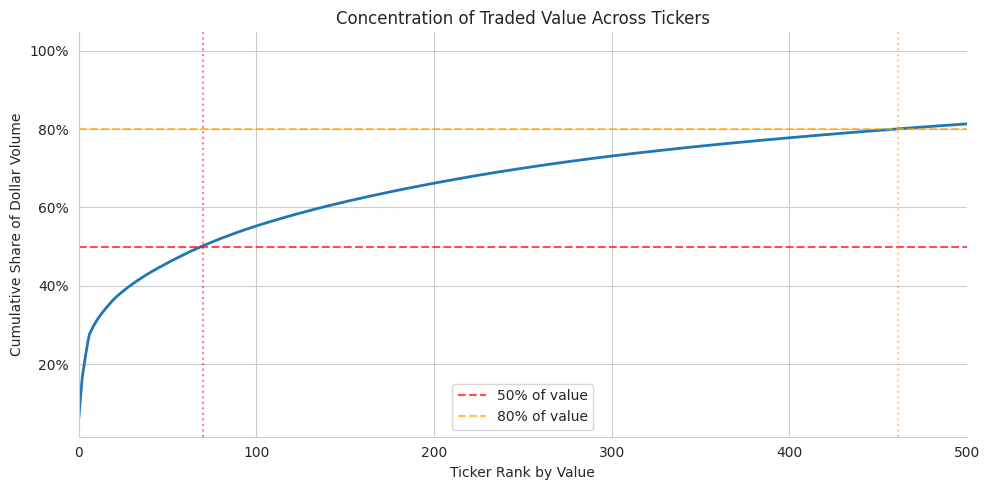

Tickers needed for 50% of value: 70
Tickers needed for 80% of value: 461


In [20]:
if HAS_MESSAGE_DATA and len(trade_df) > 0:
    # Plot cumulative concentration
    cum_val = trade_summary.select(pl.col("share_of_value").cum_sum()).to_series().to_numpy()

    fig, ax = plt.subplots(figsize=(10, 5))
    ax.plot(np.arange(len(cum_val)), cum_val, linewidth=2)
    ax.axhline(0.5, color="red", linestyle="--", alpha=0.7, label="50% of value")
    ax.axhline(0.8, color="orange", linestyle="--", alpha=0.7, label="80% of value")

    # Find how many tickers needed for 50% and 80%
    n_50 = np.searchsorted(cum_val, 0.5) + 1
    n_80 = np.searchsorted(cum_val, 0.8) + 1

    ax.axvline(n_50, color="red", linestyle=":", alpha=0.5)
    ax.axvline(n_80, color="orange", linestyle=":", alpha=0.5)

    ax.set_title("Concentration of Traded Value Across Tickers")
    ax.set_ylabel("Cumulative Share of Dollar Volume")
    ax.set_xlabel("Ticker Rank by Value")
    ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
    ax.legend()
    ax.set_xlim(0, min(500, len(cum_val)))
    sns.despine()
    plt.tight_layout()
    plt.show()

    print(f"Tickers needed for 50% of value: {n_50}")
    print(f"Tickers needed for 80% of value: {n_80}")

**Key Insight**: A small fraction of tickers accounts for most of the traded value.
This concentration is typical of equity markets - a few highly liquid names dominate activity.

## Save Output for Downstream Notebooks

Save the trade summary for use by `06_itch_intraday_patterns` and
`07_itch_stylized_facts`.

In [21]:
if HAS_MESSAGE_DATA and len(trade_df) > 0:
    # Save trade summary for downstream notebooks
    output_path = OUTPUT_DIR / "trade_summary.parquet"
    trade_summary.write_parquet(output_path)
    print(f"Saved trade summary to {output_path}")

    # Save canonical trades table for notebooks 06/07
    # This is the single source of truth for trade extraction,
    # using enriched E/C files where available
    trades_path = OUTPUT_DIR / "trades.parquet"
    trade_df.write_parquet(trades_path)
    print(f"Saved canonical trades to {trades_path}")
    print(f"  {len(trade_df):,} trades across {trade_df['ticker'].n_unique():,} tickers")

Saved trade summary to /home/stefan/ml4t/code/03_market_microstructure/output/nasdaq_itch/trading_activity/trade_summary.parquet


Saved canonical trades to /home/stefan/ml4t/code/03_market_microstructure/output/nasdaq_itch/trading_activity/trades.parquet
  10,194,361 trades across 8,915 tickers


## Key Takeaways

1. **Message volume**: this single NASDAQ session carries ~423M ITCH messages,
   dominated by adds (A, 184.7M) and deletes (D, 180.3M); executions (E, 8.4M)
   are a small slice - most orders are posted and then cancelled, not traded.
2. **Concentration**: dollar volume is heavily concentrated - just 70 tickers
   reach 50% of traded value and 461 reach 80%.
3. **Top 50 tickers** account for 45.6% of total dollar volume - nearly half.

**Next**: See `06_itch_intraday_patterns` for time-of-day analysis.

---

## Reference

Bouchaud, J.-P., Bonart, J., Donier, J., & Gould, M. (2018).
*Trades, Quotes and Prices: Financial Markets Under the Microscope*.
Cambridge University Press.
[https://doi.org/10.1017/9781009028943](https://doi.org/10.1017/9781009028943)